Day 2：线性单元和梯度下降
## 1. 今天学习的内容
学习了《零基础入门深度学习》第 2 章：
线性单元和梯度下降
主要学习内容：
线性单元
线性模型
监督学习与无监督学习
目标函数
梯度下降
随机梯度下降 SGD
使用线性单元预测工资

## 2. 线性单元是什么

上一章的感知器使用阶跃函数作为激活函数：

def f(x):
    return 1 if x > 0 else 0

它的输出通常是：

0 或 1

这一章把激活函数改成：

f = lambda x: x

也就是：

输入多少，就输出多少

因此模型变成：

y = w · x + b

线性单元返回的是连续的实数，所以更适合解决回归问题，例如根据工作年限预测工资。

## 3. 线性模型的理解

如果只考虑一个特征：

x = 工作年限

模型可以写成：

y = w * x + b

其中：

x：输入特征
w：权重
b：偏置
y：模型预测结果

例如：

w = 1000
b = 500
x = 5

那么：

y = 1000 * 5 + 500
  = 5500

也就是预测工作 5 年的人月薪为 5500。
多维特征向量，感觉表达上和线代有点像

## 4. 监督学习
这一章使用的是监督学习。

训练数据不仅有输入：

x

还有对应的正确答案：

label

例如：

工作 5 年   -> 工资 5500
工作 3 年   -> 工资 2300
工作 8 年   -> 工资 7600
工作 1.4 年 -> 工资 1800
工作 10.1 年 -> 工资 11400

模型通过这些已经知道答案的数据进行训练，然后学习输入和输出之间的规律。
好像在本科阶段听得最多的关于监督学习和无监督学习的区别的说法是数据是否有标签，实际上就是每个训练样本既包括输入特征 ，也包括对应
的输出。无监督学习的话直接从数据本身挖掘出隐藏的结构、模式和规律，直观上就是没有标签y


## 5. 梯度下降

目前对梯度下降的理解是：

计算当前误差-找到让误差下降的方向-调整权重 w 和偏置 b-再次计算-继续调整

梯度表示函数上升最快的方向，所以一般我们计算时用的梯度的反方向就是函数下降最快的方向。

所以梯度下降可以理解为每次朝着让误差变小的方向走一点。
整体看了一般求导推导，主要来说就是用链式法则和基本求导。

## 6.SGD 随机梯度下降

普通的批梯度下降需要计算整个训练集之后再更新参数。相当于老师批完全班的作业再去总结

SGD 的做法是：

拿一个样本-预测-计算误差-更新一次权重-再处理下一个样本

因此在训练数据很多的时候，SGD 通常更加实用。虽然说每次更新并不一定按照减少E的方向，主要是噪声带来的一定干扰。SGD是批完一个同学的作业就总结去讲一下，可以说和前面一章感知器更新参数时比较相似

## 7. 目前还需要继续理解的问题
为什么目标函数通常使用平方误差？
学习率应该怎么选择？

这些问题后面继续学习和验证。

weights = [1124.0634970262222]
bias = 85.48528882583837
Work 3.4 years, monthly salary = 3907.30
Work 15 years, monthly salary = 16946.44
Work 1.5 years, monthly salary = 1771.58
Work 6.3 years, monthly salary = 7167.09


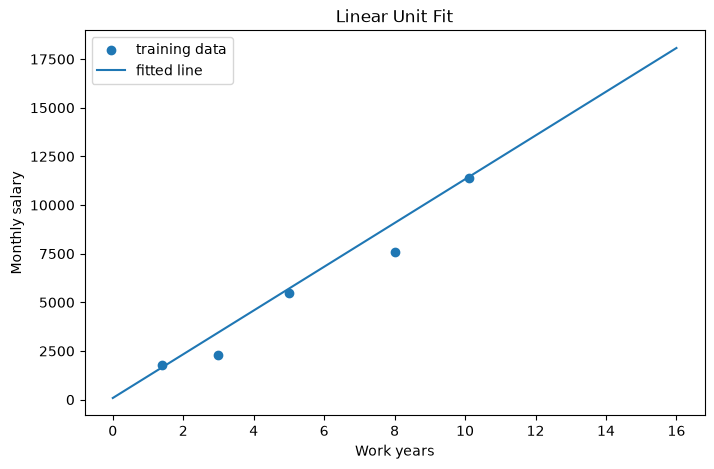

In [4]:
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np


class VectorOp:
    @staticmethod
    def dot(x, y):
        return reduce(
            lambda a, b: a + b,
            VectorOp.element_multiply(x, y),
            0.0
        )

    @staticmethod
    def element_multiply(x, y):
        return list(
            map(lambda xy: xy[0] * xy[1], zip(x, y))
        )

    @staticmethod
    def element_add(x, y):
        return list(
            map(lambda xy: xy[0] + xy[1], zip(x, y))
        )

    @staticmethod
    def scalar_multiply(v, s):
        return list(map(lambda e: e * s, v))


class Perceptron:
    def __init__(self, input_num, activator):
        self.activator = activator
        self.weights = [0.0] * input_num
        self.bias = 0.0

    def predict(self, input_vec):
        weighted_sum = VectorOp.dot(
            input_vec,
            self.weights
        ) + self.bias

        return self.activator(weighted_sum)

    def train(self, input_vecs, labels, iteration, rate):
        for i in range(iteration):
            self._one_iteration(
                input_vecs,
                labels,
                rate
            )

    def _one_iteration(self, input_vecs, labels, rate):
        samples = zip(input_vecs, labels)

        for input_vec, label in samples:
            output = self.predict(input_vec)

            self._update_weights(
                input_vec,
                output,
                label,
                rate
            )

    def _update_weights(
        self,
        input_vec,
        output,
        label,
        rate
    ):
        delta = label - output

        self.weights = VectorOp.element_add(
            self.weights,
            VectorOp.scalar_multiply(
                input_vec,
                rate * delta
            )
        )

        self.bias += rate * delta


f = lambda x: x


class LinearUnit(Perceptron):
    def __init__(self, input_num):
        Perceptron.__init__(
            self,
            input_num,
            f
        )


def get_training_dataset():
    input_vecs = [
        [5],
        [3],
        [8],
        [1.4],
        [10.1]
    ]

    labels = [
        5500,
        2300,
        7600,
        1800,
        11400
    ]

    return input_vecs, labels


def train_linear_unit():
    linear_unit = LinearUnit(1)

    input_vecs, labels = get_training_dataset()

    linear_unit.train(
        input_vecs,
        labels,
        10,
        0.01
    )

    return linear_unit


def plot(linear_unit):
    input_vecs, labels = get_training_dataset()

    x = [item[0] for item in input_vecs]
    y = labels

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, label='training data')

    x_line = np.linspace(0, 16, 200)
    y_line = [
        linear_unit.predict([x_value])
        for x_value in x_line
    ]

    plt.plot(x_line, y_line, label='fitted line')

    plt.xlabel('Work years')
    plt.ylabel('Monthly salary')
    plt.title('Linear Unit Fit')
    plt.legend()
    plt.show()


if __name__ == '__main__':
    linear_unit = train_linear_unit()

    print("weights =", linear_unit.weights)
    print("bias =", linear_unit.bias)

    print(
        "Work 3.4 years, monthly salary = %.2f"
        % linear_unit.predict([3.4])
    )

    print(
        "Work 15 years, monthly salary = %.2f"
        % linear_unit.predict([15])
    )

    print(
        "Work 1.5 years, monthly salary = %.2f"
        % linear_unit.predict([1.5])
    )

    print(
        "Work 6.3 years, monthly salary = %.2f"
        % linear_unit.predict([6.3])
    )

    plot(linear_unit)